## Settings

In [22]:
## auto reload modules
%reload_ext autoreload
%autoreload 2

## Dependencies

In [ ]:
## libraries
import sys
import logging
from pathlib import Path

## path
root = Path.cwd().resolve().parent
sys.path.insert(0, str(root))

## modules
from src.estimators.factories import load_estimators
from src.data.builders import (
    load_processed_data, 
    load_falsified_data
)
from src.evaluators.falsifying import (
    train_falsified_transfer,
    train_falsified_recovery,
    train_falsified_consensus,
    compile_falsified_transfer,
    compile_falsified_recovery,
    compile_falsified_consensus,
    stat_falsified_test,
    stat_falsified_summary,
)
from src.visualizers.visualizing import plot_consensus

## constants
from src.evaluators.metrics import (
    FRONTIER_METRICS,
    CONSENSUS_METRICS
)
from src.evaluators.config import (
    FEAT_X, 
    FEAT_Z, 
    TARGET
)

## Initialization

In [ ]:
## reproducibility
N_REPEATS = 30
RANDOM_STATE = 42

## load data and models
_disable = logging.root.manager.disable
logging.disable(logging.INFO)
try:
    data_proc = load_processed_data()
    data_fals = load_falsified_data()
finally:
    logging.disable(_disable)
    models = load_estimators(random_state = RANDOM_STATE)

## view data shape
n_obs, n_feat = data_proc.shape
print(f"Original Data: {n_feat} features, {n_obs} observations")
print("Falsified Data:")
for method, data in data_fals.items():
    n_r, n_c = data.shape
    print(f" - {method}: {n_c} features, {n_r} observations")

## view model surface
n_mods = len(models)
print(f"Learned Models: {n_mods} estimators")

Original Data: 32 features, 25 observations
Falsified Data:
 - random_generate: 32 features, 25 observations
 - target_remap: 32 features, 25 observations
 - vector_generate: 32 features, 25 observations
Learned Models: 9 estimators


## Training

In [ ]:
## train falsified transfer
if "results_dict_falsified_transfer" not in globals():
    results_dict_falsified_transfer = train_falsified_transfer(
        data_proc = data_proc,
        data_fals = data_fals,
        models = models,
        feat_x = FEAT_X,
        feat_z = FEAT_Z,
        target = TARGET,
        group = "domain",
        n_repeats = N_REPEATS,
        random_state = RANDOM_STATE
    )

In [ ]:
## train falsified structural recovery
if "results_dict_falsified_recovery" not in globals():
    results_dict_falsified_recovery = train_falsified_recovery(
        data_proc = data_proc,
        data_fals = data_fals,
        models = models,
        feat_x = FEAT_X,
        feat_z = FEAT_Z,
        target = TARGET,
        n_repeats = N_REPEATS,
        random_state = RANDOM_STATE,
    )

In [ ]:
## train falsified pairwise consensus
if "results_dict_falsified_consensus" not in globals():
    results_dict_falsified_consensus = train_falsified_consensus(
        data_proc = data_proc,
        data_fals = data_fals,
        models = models,
        feat_x = FEAT_X,
        feat_z = FEAT_Z,
        target = TARGET,
        n_repeats = N_REPEATS,
        random_state = RANDOM_STATE
    )

## Post-Processing

In [ ]:
## compile falsified transfer results
results_falsified_transfer = compile_falsified_transfer(
    results = results_dict_falsified_transfer
)

## compile falsified structural recovery results
results_falsified_recovery = compile_falsified_recovery(
    results = results_dict_falsified_recovery
)

## compile falsified pairwise consensus results
results_falsified_consensus = compile_falsified_consensus(
    results = results_dict_falsified_consensus
)

## Transfer Falsification Evaluation

Three falsification types (target remap, random generate, vector generate) are applied to the processed datasets while the evaluation target remains fixed. Model sensitivity is evaluated with LOGO-CV (domain) under frozen and retrained protocols, allowing original-data EI transfer performance to be compared against deliberately corrupted inputs.

## Transfer Falsifiability Test

This section tests whether models produce stronger EI transfer metrics on original data than on falsified data. Under the frozen protocol, models trained on original data are evaluated directly on falsified inputs. Under the retrain protocol, models are refit on falsified data and compared back to the original-data baseline.

In [ ]:
## wilcoxon signed-rank test for falsified transfer
results_table_transfer = stat_falsified_test(
    results = results_falsified_transfer,
    feat_value = ["ei"],
    feat_pairs = ["model", "group"]
)

display(results_table_transfer)

Paired One-Sided Test (Wilcoxon Signed-Rank): n = 45
H₀: Δ EI ≤ 0
H₁: Δ EI > 0
Median Δ EI: Median of paired differences, not the difference of marginal medians
Rank-biserial r: Paired effect size, positive values favor original
One-sided p: Wilcoxon signed-rank p-value for H₁
Holm-adj. p: Holm-Bonferroni adjusted one-sided p-value
Diff.: Yes if Holm-adj. p < 0.05 and Median Δ > 0
Significance codes reflect Holm-adj. p
*** p < 0.001, ** p < 0.01, * p < 0.05


Median Δ EI Rank-biserial r One-sided p Holm-adj. p  \
Frontier Method                                                                
frozen   target remap         0.0291          0.3739      0.0142      0.0142   
         random generate      0.0532          0.8415      0.0000      0.0000   
         vector generate      0.0229          0.6638      0.0000      0.0001   
retrain  target remap         0.0631          0.5420      0.0006      0.0021   
         random generate      0.0474          0.5478      0.0005      0.0021   
         vector generate      0.0218          0.5188      0.0010      0.0021   

                         Sig. Diff.  
Frontier Method                      
frozen   target remap       *   Yes  
         random generate  ***   Yes  
         vector generate  ***   Yes  
retrain  target remap      **   Yes  
         random generate   **   Yes  
         vector generate   **   Yes

In [ ]:
## median falsified transfer metrics
transfer_summary = stat_falsified_summary(
    results = results_falsified_transfer,
    metrics = FRONTIER_METRICS
)

display(transfer_summary)

vr      mv      ms      ei
Frontier Method                                      
original original         0.0  0.0000  5.1100  0.7994
frozen   target remap     0.2  0.4003  5.0082  0.7612
         random generate  0.0  0.0000  7.9842  0.7466
         vector generate  0.0  0.0000  6.8557  0.7511
retrain  target remap     0.0  0.0000  5.8559  0.7451
         random generate  0.0  0.0000  5.7517  0.7468
         vector generate  0.0  0.0000  5.2695  0.7527

All three falsification types yield significant EI degradation under both the frozen and retrained protocols, with effect sizes comparable across types. Target remap corrupts the target only, while random and vector generation corrupt the input features, yet the resulting EI losses are of similar magnitude. Retraining does not restore original EI performance for any falsification type, and for target remap the retrained contrast is the largest observed shift.

## Structural Recovery Evaluation
The same three falsification types are applied while the observed target remains unchanged, isolating whether structural recovery depends on coherent graph-derived structure rather than on incidental feature variation. Model performance is evaluated with LOGO-CV (domain) under frozen and retrained protocols using cross-validated predictions on the falsified inputs.

## Structural Recovery Test
This section tests whether original data yields stronger agreement between model predictions and the observed target than falsified data. It evaluates domain-level structural recovery under the frozen and retrained protocols, treating each falsification method as an independent destructive intervention on the input signal.

In [29]:
## wilcoxon signed-rank test for falsified structural recovery
results_table_recovery = stat_falsified_test(
    results = results_falsified_recovery,
    feat_value = ["ci"],
    feat_pairs = ["model", "group"]
)

display(results_table_recovery)

Paired One-Sided Test (Wilcoxon Signed-Rank): n = 45
H₀: Δ CI ≤ 0
H₁: Δ CI > 0
Median Δ CI: Median of paired differences, not the difference of marginal medians
Rank-biserial r: Paired effect size, positive values favor original
One-sided p: Wilcoxon signed-rank p-value for H₁
Holm-adj. p: Holm-Bonferroni adjusted one-sided p-value
Diff.: Yes if Holm-adj. p < 0.05 and Median Δ > 0
Significance codes reflect Holm-adj. p
*** p < 0.001, ** p < 0.01, * p < 0.05


Median Δ CI Rank-biserial r One-sided p Holm-adj. p  \
Frontier Method                                                                
frozen   target remap         0.2732          0.8551      0.0000      0.0000   
         random generate      0.2219          0.8937      0.0000      0.0000   
         vector generate      0.2233          0.8918      0.0000      0.0000   
retrain  target remap         0.1916          0.8686      0.0000      0.0000   
         random generate      0.1690          0.7604      0.0000      0.0000   
         vector generate      0.2500          0.8531      0.0000      0.0000   

                         Sig. Diff.  
Frontier Method                      
frozen   target remap     ***   Yes  
         random generate  ***   Yes  
         vector generate  ***   Yes  
retrain  target remap     ***   Yes  
         random generate  ***   Yes  
         vector generate  ***   Yes

In [30]:
## median falsified structural recovery metrics
recovery_summary = stat_falsified_summary(
    results = results_falsified_recovery,
    metrics = CONSENSUS_METRICS
)

display(recovery_summary)

rho     rbo     dcr      ci
Frontier Method                                      
original original         0.7  0.9098  0.8469  0.8713
frozen   target remap    -0.3  0.8098  0.6111  0.5620
         random generate  0.0  0.8098  0.6063  0.5761
         vector generate -0.1  0.8098  0.6352  0.6000
retrain  target remap     0.1  0.8098  0.6310  0.6344
         random generate  0.3  0.8280  0.5982  0.6654
         vector generate -0.1  0.8098  0.6229  0.5799

Every falsification type produces a significant loss of structural recovery under both protocols, with rank-biserial effect sizes at or near the theoretical maximum. Rank correlation with the observed target collapses from positive under the original baseline to near zero or negative under every falsified setting, including target remap. Retraining does not restore structural recovery; several retrained variants remain as far below the original as their frozen counterparts.

## Pairwise Consensus Evaluation

The same falsification types are applied to assess whether fitted frontier structure remains stable when informative input geometry is destroyed. Pairwise agreement is evaluated across model frontiers under the frozen protocol, holding model fits anchored to the original empirical manifold and focusing on inter-model consistency rather than direct prediction of the observed target.

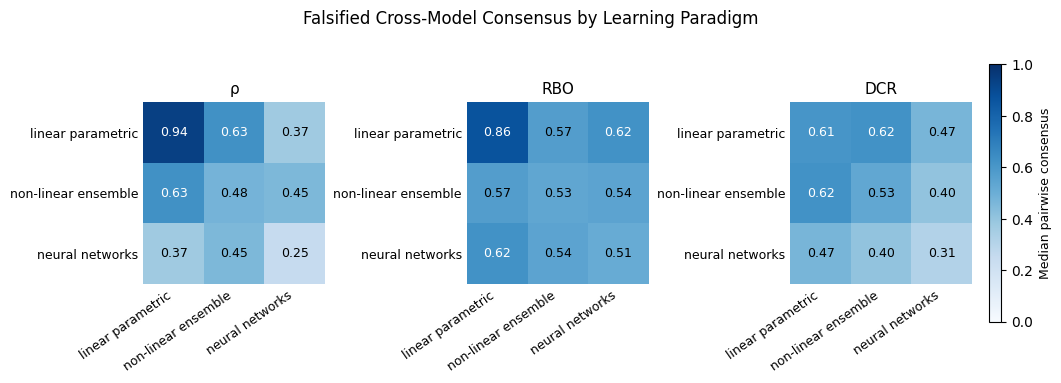

In [32]:
## paradigm-level pairwise consensus heatmap
results_falsified_consensus_plot = results_falsified_consensus.loc[
    (results_falsified_consensus["condition"] == "falsified")
    & (results_falsified_consensus["track"] == "frozen")
].copy()

fig, axes, matrices = plot_consensus(
    results = results_falsified_consensus_plot,
    title = "Falsified Cross-Model Consensus by Learning Paradigm"
)

falsified_consensus_figures = {"frozen": fig}
falsified_consensus_axes = {"frozen": axes}
falsified_consensus_matrices = {"frozen": matrices}

The paradigm-level consensus exhibit is restricted to frozen falsification, so model frontiers remain anchored to the original empirical manifold while the inputs are destroyed. Frozen target remap is identical to the original baseline because it leaves the input features untouched and changes only the target, so fitted frontiers are unchanged by construction and the paired test is undefined. Under frozen random and vector generation, pairwise agreement declines sharply, indicating that cross-model consensus depends on coherent event-network geometry rather than on a relearned null manifold.